In [8]:
## :: Multi-Index Objects : 

In [9]:
import numpy as np
import pandas as pd

## Series is 1D and DataFrames are 2D objects :

--> But Why? 

--> And what exactly is index?

In [10]:
## Seires mai hame koi ak single data fetch karne ke liye one - piece of information dena pdta hai.

## Dataframe mai hame koi ak single data fetch karne ke liye two - piece of information dena pdta hai.

In [11]:
## can we have multiple index in Series ? Let's try " :

index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a = pd.Series([1,2,3,4,5,6,7,8] , index=index_val)
a

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [12]:
## Fetching value 4 :

a[('cse' , 2022)]

np.int64(4)

In [13]:
a[('cse')]  # Error 

#--> Solution : multiindex series(also known as Hierarchial Indexing).
#--> multiple index levels within a single index. 

KeyError: 'cse'

In [16]:
## How to create muli-index object :


In [15]:
# 1. pd.MultiIndex.from_tuples() :

index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex.levels[0]   # output : Index(['cse', 'ece'], dtype='str')

multiindex.levels[1]   # output : Index([2019, 2020, 2021, 2022], dtype='int64')


Index([2019, 2020, 2021, 2022], dtype='int64')

In [17]:
# 2. pd.MultiIndex.from_product() :

index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_product([ ['cse' , 'ece'] , [2019 ,2020 , 2021 , 2022] ])
multiindex


MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [18]:
## Creating a series with multiindex object :

s = pd.Series( [1,2,3,4,5,6,7,8] , index = multiindex)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [19]:
## Fetching items from a multiindex Series : 

s[('cse' , 2022)]

s[('cse')]



2019    1
2020    2
2021    3
2022    4
dtype: int64

In [20]:
## Unstack : 

# --> Iss method se hum kisi bhi multiindex Series ko dataframe mai convert krr skte hai. 

temp = s.unstack()
temp



,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [21]:
## stack : 

#--> Ye kisi bhi dataframe ko multi-index series mai convert krr deta hai.

temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [22]:
## Why should we use Multi-index Series : 

#--> Higher dimension data ko like( 5d , 10d , 15d ) ko lower dimension like(series and dataframe) mai represent krwa skte hai.


In [ ]:
######################################################################################################################################################

In [ ]:
## Multi-index DataFrame : 

In [23]:
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16],
    ],
    index = multiindex,
    columns = ['avg_package','students']
)

branch_df1





avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [24]:
branch_df1.loc['cse']
branch_df1.loc['ece']


,avg_package,students
2019,9,10
2020,11,12
2021,13,14
2022,15,16


In [25]:
branch_df1['students']
branch_df1['avg_package']





cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [26]:
# multiindex df from columns perspective
branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
    ],
    index = [2019,2020,2021,2022],
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df2



delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [27]:
branch_df2['delhi']
branch_df2['mumbai']


,avg_package,students
2019,0,0
2020,0,0
2021,0,0
2022,0,0


In [28]:
branch_df2['delhi']['avg_package']
branch_df2['mumbai']['avg_package']



2019    0
2020    0
2021    0
2022    0
Name: avg_package, dtype: int64

In [29]:
branch_df2.loc[2019]
branch_df2.loc[2020]



delhi   avg_package    3
        students       4
mumbai  avg_package    0
        students       0
Name: 2020, dtype: int64

In [30]:
# Multiindex df in terms of both cols and index

branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

## Stacking And Unstacking : 

In [47]:
####  stack   : columns becomes rows.
####  unstack : rows becomes columns.


In [32]:
branch_df1.unstack()


avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

In [35]:
branch_df1.unstack().unstack()

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

In [40]:
branch_df2.unstack().unstack()


2019  2020  2021  2022
delhi  avg_package     1     3     5     7
       students        2     4     6     8
mumbai avg_package     0     0     0     0
       students        0     0     0     0

In [43]:
branch_df2.stack().stack()

2019  avg_package  delhi     1
                   mumbai    0
      students     delhi     2
                   mumbai    0
2020  avg_package  delhi     3
                   mumbai    0
      students     delhi     4
                   mumbai    0
2021  avg_package  delhi     5
                   mumbai    0
      students     delhi     6
                   mumbai    0
2022  avg_package  delhi     7
                   mumbai    0
      students     delhi     8
                   mumbai    0
dtype: int64

## Working with multi-index dataframes : 

### head and tail : 

In [50]:
branch_df3.head()
branch_df3.tail()

delhi               mumbai         
         avg_package students avg_package students
cse 2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### shape : 

In [51]:
branch_df3.shape

(8, 4)

### info : 

In [52]:
branch_df3.info()

<class 'pandas.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 827.0 bytes


### duplicated -> isnull : 

In [53]:
branch_df3.duplicated()

cse  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [54]:
branch_df3.isnull()

delhi               mumbai         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

### Extracting rows  : 

In [57]:
#### single rows : 

branch_df3.loc[('cse' , 2022)]


delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

In [60]:
##### multiple rows : 

branch_df3.iloc[0:5:2]


delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

### Extracting cols : 

In [61]:
branch_df3


delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [62]:
branch_df3['delhi']['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [64]:
branch_df3.iloc[:,1:3]


delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

### Extracting both cols and rows : 

In [67]:
## [0,4]----> rows , [1,2]----> cols.

In [68]:
branch_df3.iloc[ [0,4] , [1,2] ]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


### sort index
### both --> desending --> diff order
### based on one level

In [69]:
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [74]:
branch_df3.sort_index(ascending=False)
branch_df3.sort_index(ascending= [False , True])   # [level_1 : ( ece , cse ) : ascending-False , level_2 : ( 2019,2020,2021,2022) : ascending-True]

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [73]:
branch_df3.sort_index(level = 0 , ascending= [False]) 
branch_df3.sort_index(level = 1 , ascending= [False]) 

delhi               mumbai         
         avg_package students avg_package students
cse 2022           7        8           0        0
ece 2022          15       16           0        0
cse 2021           5        6           0        0
ece 2021          13       14           0        0
cse 2020           3        4           0        0
ece 2020          11       12           0        0
cse 2019           1        2           0        0
ece 2019           9       10           0        0

### multiindex dataframe ( col ) --> transpose :  


In [75]:
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [76]:
branch_df3.transpose()


cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

### swaplevel : 

In [78]:
branch_df3.swaplevel()

delhi               mumbai         
         avg_package students avg_package students
2019 cse           1        2           0        0
2020 cse           3        4           0        0
2021 cse           5        6           0        0
2022 cse           7        8           0        0
2019 ece           9       10           0        0
2020 ece          11       12           0        0
2021 ece          13       14           0        0
2022 ece          15       16           0        0

In [79]:
branch_df3.swaplevel(axis = 1)

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

## Long V/S Wide Data : 

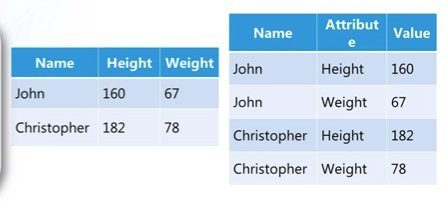


**Wide format** is where we have a single row for every data point with multiple columns to hold the values of various attributes.

**Long format** is where, for each data point we have as many rows as the number of attributes and each row contains the value of a particular attribute for a given data point.

### melt : 


In [83]:
#--> Wide data format ko long data format mai convert krta hai.

In [88]:
## Ex_1 : 

pd.DataFrame({'cse' : [120]})

,cse
0,120


In [87]:
pd.DataFrame({'cse' : [120]}).melt()

,variable,value
0,cse,120


In [90]:
## Ex_2 : 
pd.DataFrame({'cse' : [120] , 'ece': [120], 'mech' : [50] })

,cse,ece,mech
0,120,120,50


In [92]:
pd.DataFrame({'cse' : [120] , 'ece': [120], 'mech' : [50] }).melt(var_name = 'branch', value_name = 'num_students')

,branch,num_students
0,cse,120
1,ece,120
2,mech,50


In [93]:
## Ex_3 :  [wide data to long data]

pd.DataFrame(
    {
        'branch':['cse','ece','mech'],
        '2020':[100,150,60],
        '2021':[120,130,80],
        '2022':[150,140,70]
    }
).melt(id_vars=['branch'],var_name='year',value_name='students')

,branch,year,students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


In [94]:
##--> melt real world example : 

death = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-21\time_series_covid19_deaths_global.csv')
confirm = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-21\time_series_covid19_confirmed_global.csv')

In [95]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [96]:
death.shape

(289, 1081)

In [97]:
confirm.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [103]:
death = death.melt(id_vars = ['Province/State' , 'Country/Region' , 'Lat' , 'Long'] , var_name = 'date' , value_name = 'num_deaths')
confirm = confirm.melt(id_vars = ['Province/State' , 'Country/Region' , 'Lat' , 'Long'] , var_name = 'date' , value_name = 'num_cases')

In [105]:
death.head()

,Province/State,Country/Region,Lat,Long,date,num_deaths
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [106]:
confirm.head()

,Province/State,Country/Region,Lat,Long,date,num_cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [108]:
## merging both death and confirm dataframe : 

confirm.merge(death , on=['Province/State' , 'Country/Region' , 'Lat' , 'Long' , 'date'])[ ['Country/Region' , 'date' , 'num_cases' , 'num_deaths'] ]

,Country/Region,date,num_cases,num_deaths
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,703228,5708
311249,Winter Olympics 2022,1/2/23,535,0
311250,Yemen,1/2/23,11945,2159
311251,Zambia,1/2/23,334661,4024


## Pivot Table : 


In [5]:
##  The pivot table takes simple column-Wise data as input , and groups the entries into a two-dimensional table that provides a multi-dimensional 
##  summarization of the data , And it is generally used for categorical columns.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [9]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
## find the avg total_bill according to the gender : 

df.groupby('sex')[ ['total_bill'] ].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [16]:
## find the avg total_bill according to the gender and smoker : 

df.groupby(['sex' , 'smoker'])[ ['total_bill'] ].mean()


## use unstack to make the smoker column into row : 

df.groupby(['sex' , 'smoker'])[ ['total_bill'] ].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [20]:
## solving via pivot table : 

df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill')


## using aggregate function : [ default is mean ]

df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'count')
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'mean')
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'std')
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'max')


smoker,Yes,No
sex,,
Male,50.81,48.33
Female,44.30,35.83


In [23]:
##  all cols together : [ don't pass the value attribute ]

df.pivot_table(index = 'sex' , columns = 'smoker' , aggfunc = 'count')['size']


smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [29]:
## multi-dimensional : 

df.pivot_table(index = ['sex' , 'smoker'] , columns = ['day' , 'time'] , values= 'total_bill' , margins = True)

day                 Thur               Fri                   Sat        Sun  \
time               Lunch Dinner      Lunch     Dinner     Dinner     Dinner   
sex    smoker                                                                 
Male   Yes     19.171000    NaN  11.386667  25.892000  21.837778  26.141333   
       No      18.486500    NaN        NaN  17.475000  19.929063  20.403256   
Female Yes     19.218571    NaN  13.260000  12.200000  20.266667  16.540000   
       No      15.899167  18.78  15.980000  22.750000  19.003846  20.824286   
All            17.664754  18.78  12.845714  19.663333  20.441379  21.410000   

day                  All  
time                      
sex    smoker             
Male   Yes     22.284500  
       No      19.791237  
Female Yes     17.977879  
       No      18.105185  
All            19.785943

In [30]:
## plotting graphs : 

df = pd.read_csv(r'C:\Users\ANUBHAV\Data_Analytics\Python\Pandas\Datasets\datasets-session-22\expense_data.csv')

In [31]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [32]:
df['Category'].value_counts()


Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [35]:
## fetching the month name from the date column : 

df.info()

df['Date'] = pd.to_datetime(df['Date'])
df.info()

Task was destroyed but it is pending!
task: <Task pending name='Task-200' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\ANUBHAV\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-201' coro=<Kernel.shell_main() running at C:\Users\ANUBHAV\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\ANUBHAV\AppData\Local\Programs\Python\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\ANUBHAV\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:2270: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return klass(values, ndim=ndim, placement=placement, refs=refs)
Task was destroyed but it is pending!
task: <Task pending name='Task-201' coro=<Kernel.shell_main() running at C:\Users\ANUBHAV\AppData\Local\Programs\P

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 36.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------     

In [38]:
df['month'] = df['Date'].dt.month_name()

df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='month'>

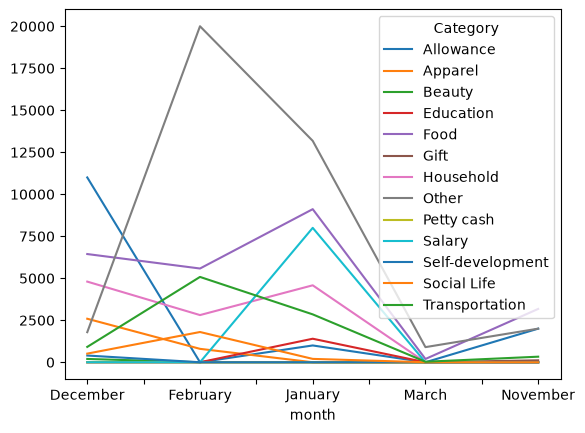

In [44]:
df.pivot_table(index = 'month' , columns= 'Category' , values = 'INR' , aggfunc = 'sum' , fill_value = 0).plot()

<Axes: xlabel='month'>

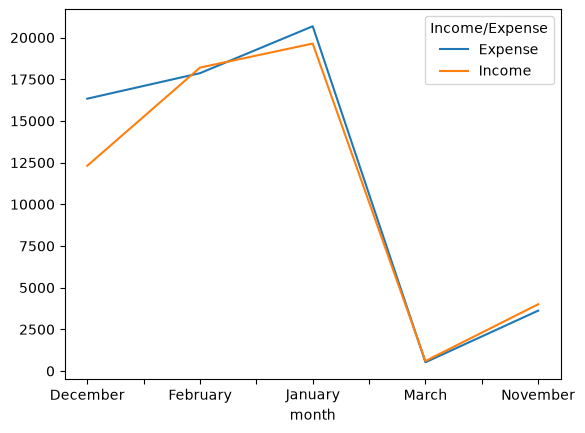

In [45]:
df.pivot_table(index = 'month' , columns= 'Income/Expense' , values = 'INR' , aggfunc = 'sum' , fill_value = 0).plot()

<Axes: xlabel='month'>

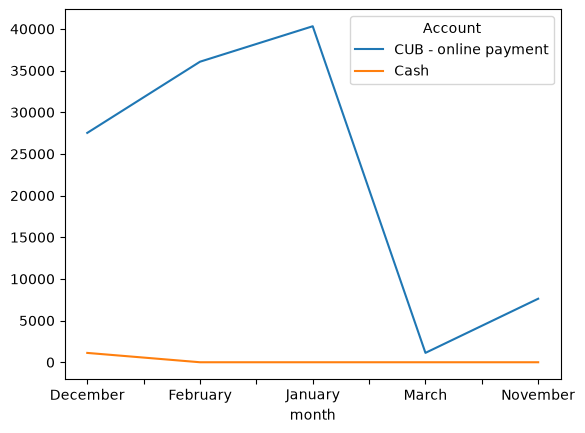

In [47]:
df.pivot_table(index = 'month' , columns= 'Account' , values = 'INR' , aggfunc = 'sum' , fill_value = 0).plot()